In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Paths in Kaggle
train_path = "/kaggle/input/datasets/mimsadiislam/chexpert/CheXpert-v1.0-small/train.csv"
valid_path = "/kaggle/input/datasets/mimsadiislam/chexpert/CheXpert-v1.0-small/valid.csv"

df = pd.read_csv(train_path)

print("Shape:", df.shape)
df.head()

Shape: (223414, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


# Data Visualization

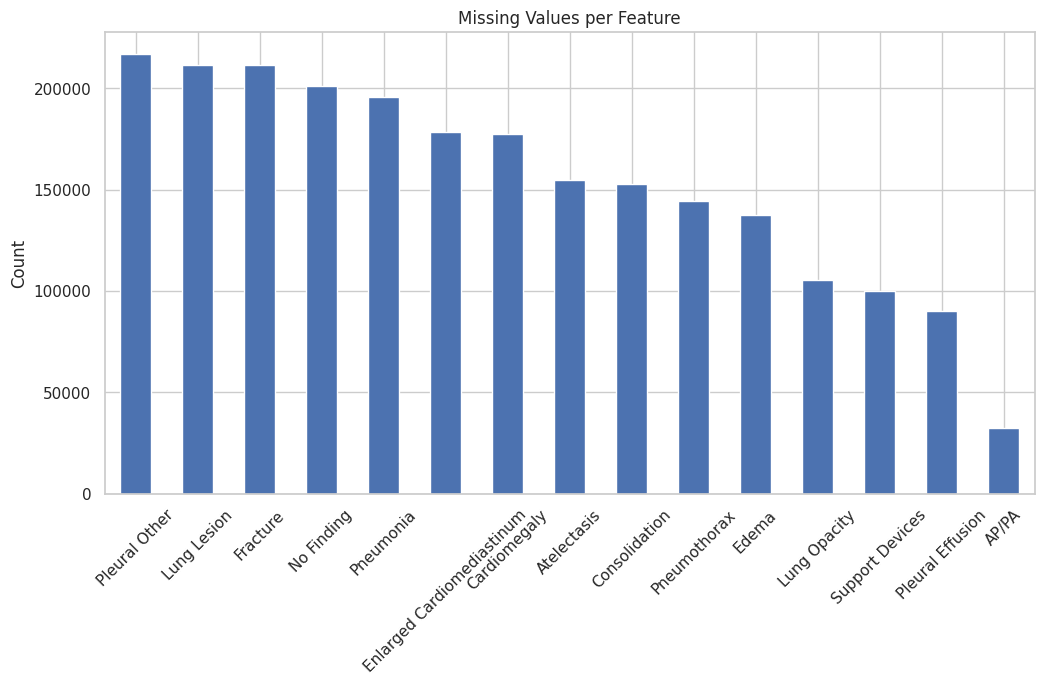

In [10]:
# Missing values overview
missing = df.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing[missing > 0].plot(kind='bar')
plt.title("Missing Values per Feature")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## A. Missing & Inconsistent Values

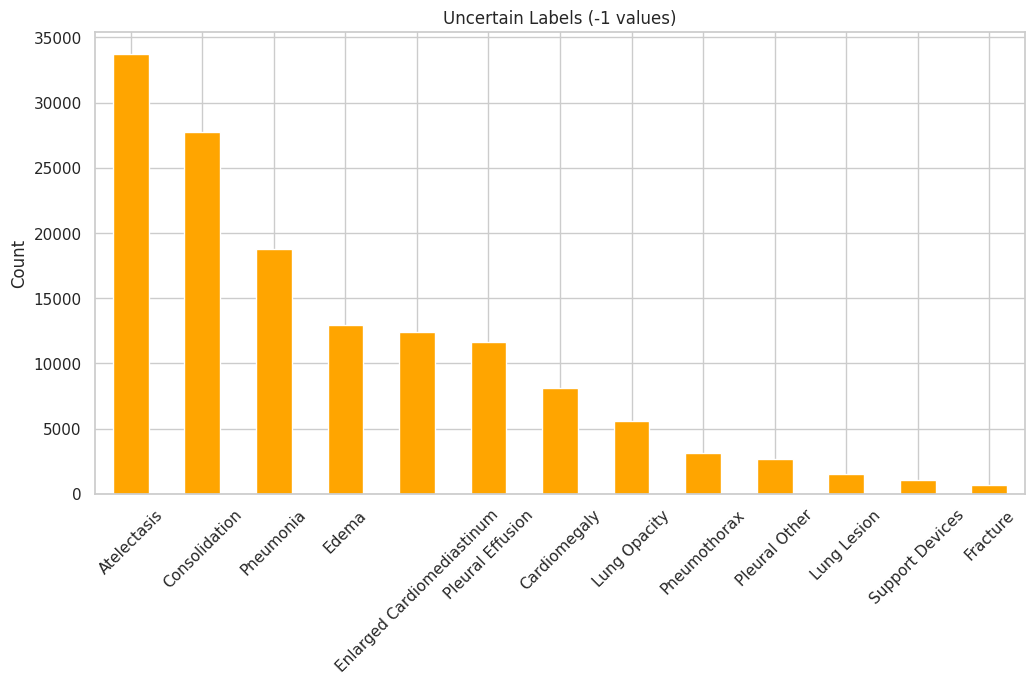

In [11]:
# Count of -1 values (uncertain labels)
uncertain_counts = {}

for col in df.columns:
    if df[col].dtype != 'object':
        uncertain_counts[col] = (df[col] == -1).sum()

uncertain_series = pd.Series(uncertain_counts).sort_values(ascending=False)

plt.figure(figsize=(12,6))
uncertain_series[uncertain_series > 0].plot(kind='bar', color='orange')
plt.title("Uncertain Labels (-1 values)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## B. Duplicate Detection

Number of duplicate rows: 0


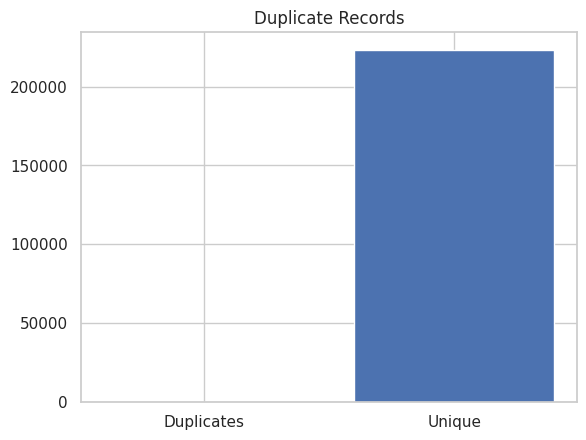

In [ ]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
# Visual check
plt.bar(["Duplicates", "Unique"], [duplicates, len(df)-duplicates])
plt.title("Duplicate Records")
plt.show()

## C. Data Type Issues

In [13]:
print(df.dtypes)

Path                           object
Sex                            object
Age                             int64
Frontal/Lateral                object
AP/PA                          object
No Finding                    float64
Enlarged Cardiomediastinum    float64
Cardiomegaly                  float64
Lung Opacity                  float64
Lung Lesion                   float64
Edema                         float64
Consolidation                 float64
Pneumonia                     float64
Atelectasis                   float64
Pneumothorax                  float64
Pleural Effusion              float64
Pleural Other                 float64
Fracture                      float64
Support Devices               float64
dtype: object


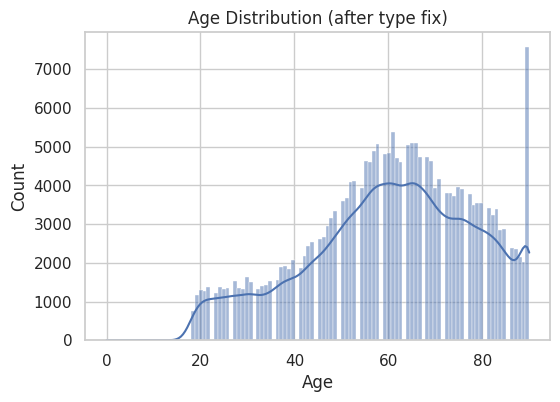

In [14]:
# Convert Age
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Check distribution after fix
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution (after type fix)")
plt.show()

## D. Outlier Detection

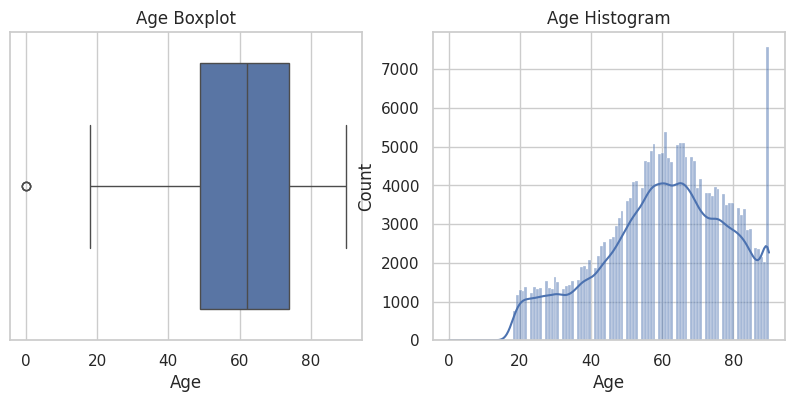

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df["Age"])
plt.title("Age Boxplot")

plt.subplot(1,2,2)
sns.histplot(df["Age"], kde=True)
plt.title("Age Histogram")

plt.show()

In [16]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]

print("Outliers detected:", len(outliers))

Outliers detected: 3


## E. Inconsistent Categorical Values

In [17]:
# Check unique values for key categorical features
categorical_cols = ["Sex", "Frontal/Lateral", "AP/PA"]

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts(dropna=False))


Sex unique values:
Sex
Male       132636
Female      90777
Unknown         1
Name: count, dtype: int64

Frontal/Lateral unique values:
Frontal/Lateral
Frontal    191027
Lateral     32387
Name: count, dtype: int64

AP/PA unique values:
AP/PA
AP     161590
NaN     32387
PA      29420
LL         16
RL          1
Name: count, dtype: int64


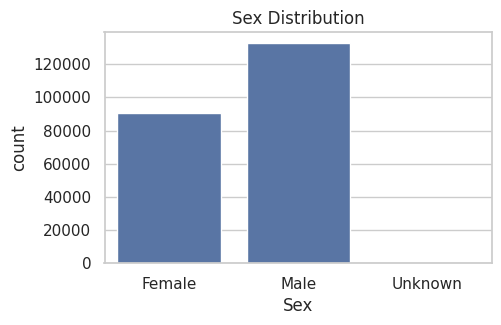

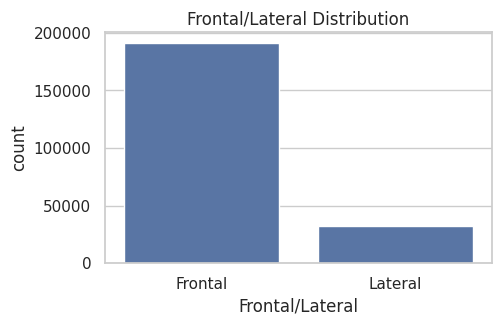

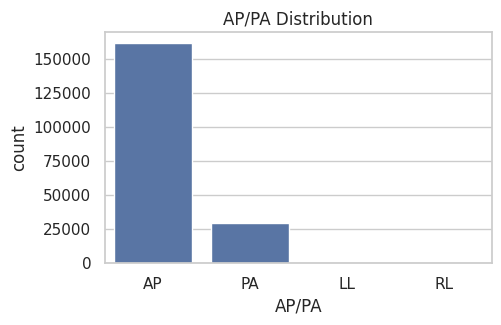

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"{col} Distribution")
    plt.show()

## Class imbalance in diseases

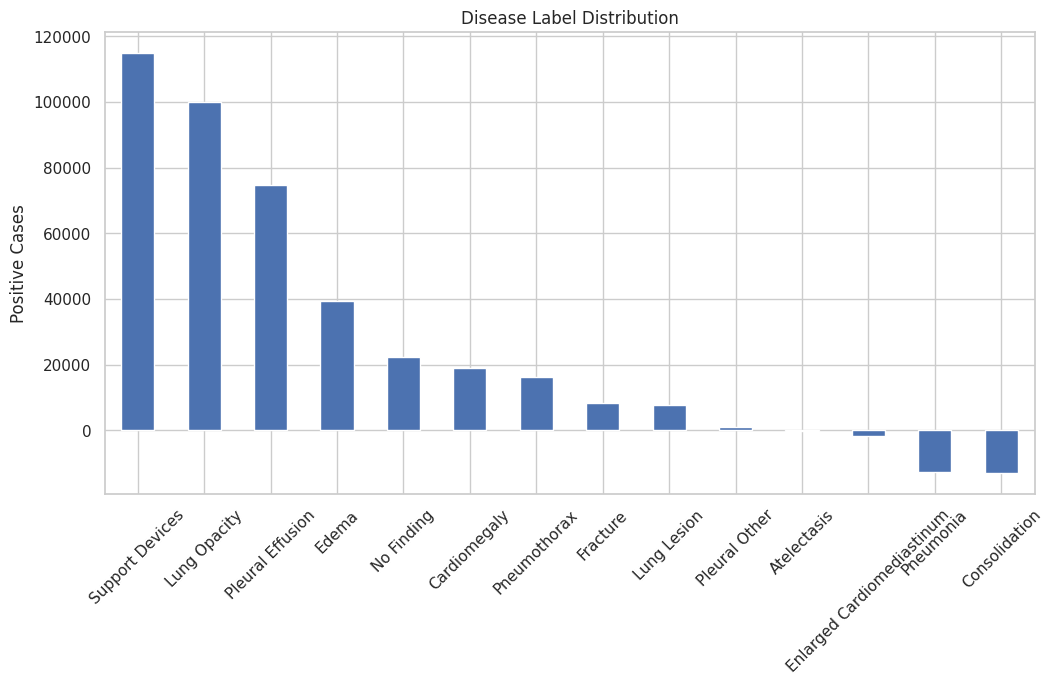

In [20]:
label_cols = df.columns[5:]  # usually labels start after metadata

label_sums = df[label_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
label_sums.plot(kind='bar')
plt.title("Disease Label Distribution")
plt.ylabel("Positive Cases")
plt.xticks(rotation=45)
plt.show()

# Data Cleaning

- remove columns like: Fracture, AP/PA
- delete the rows with No Finding 1 and then delete this column too
- remove the age outliers - there are 3 
- remove the unknown label from Sex column


In [32]:
import pandas as pd
import numpy as np

def data_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean CheXpert tabular data for phenotype clustering.

    Steps:
    1. Remove columns not useful for the problem: Fracture, AP/PA
    2. Remove rows where `No Finding == 1`, then drop `No Finding`
    3. Remove age outliers using the IQR rule
    4. Remove rows where Sex is unknown
    """

    df = df.copy()

    # -----------------------------
    # 1. Remove irrelevant columns
    # -----------------------------
    cols_to_drop = ["Fracture", "AP/PA"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors="ignore")

    # ---------------------------------------------------
    # 2. Remove healthy cases and then drop No Finding
    # ---------------------------------------------------
    if 'No Finding' in df.columns:
        df = df[df["No Finding"] != 1].copy()
        df = df.drop('No Finding', axis='columns')

    # -----------------------------
    # 3. Clean Age and remove outliers
    # -----------------------------
    if "Age" in df.columns:
        df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

        # Remove missing ages first
        df = df[df["Age"].notna()].copy()

        # IQR-based outlier removal
        q1 = df["Age"].quantile(0.25)
        q3 = df["Age"].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        df = df[(df["Age"] >= lower) & (df["Age"] <= upper)].copy()

    # -----------------------------------
    # 4. Remove unknown values from Sex
    # -----------------------------------
    if "Sex" in df.columns:
        df["Sex"] = df["Sex"].astype(str).str.strip()
        df = df[~df["Sex"].str.lower().isin(["unknown", "nan", "none", ""])]
        df = df[df["Sex"].notna()].copy()

    return df.reset_index(drop=True)

In [33]:
train_path = "/kaggle/input/datasets/mimsadiislam/chexpert/CheXpert-v1.0-small/train.csv"
valid_path = "/kaggle/input/datasets/mimsadiislam/chexpert/CheXpert-v1.0-small/valid.csv"

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)

train_clean = data_cleaning(train_df)
valid_clean = data_cleaning(valid_df)

print("Original train shape:", train_df.shape)
print("Cleaned train shape:", train_clean.shape)

print("Original valid shape:", valid_df.shape)
print("Cleaned valid shape:", valid_clean.shape)

Original train shape: (223414, 19)
Cleaned train shape: (201031, 16)
Original valid shape: (234, 19)
Cleaned valid shape: (196, 16)


# Feature Analysis

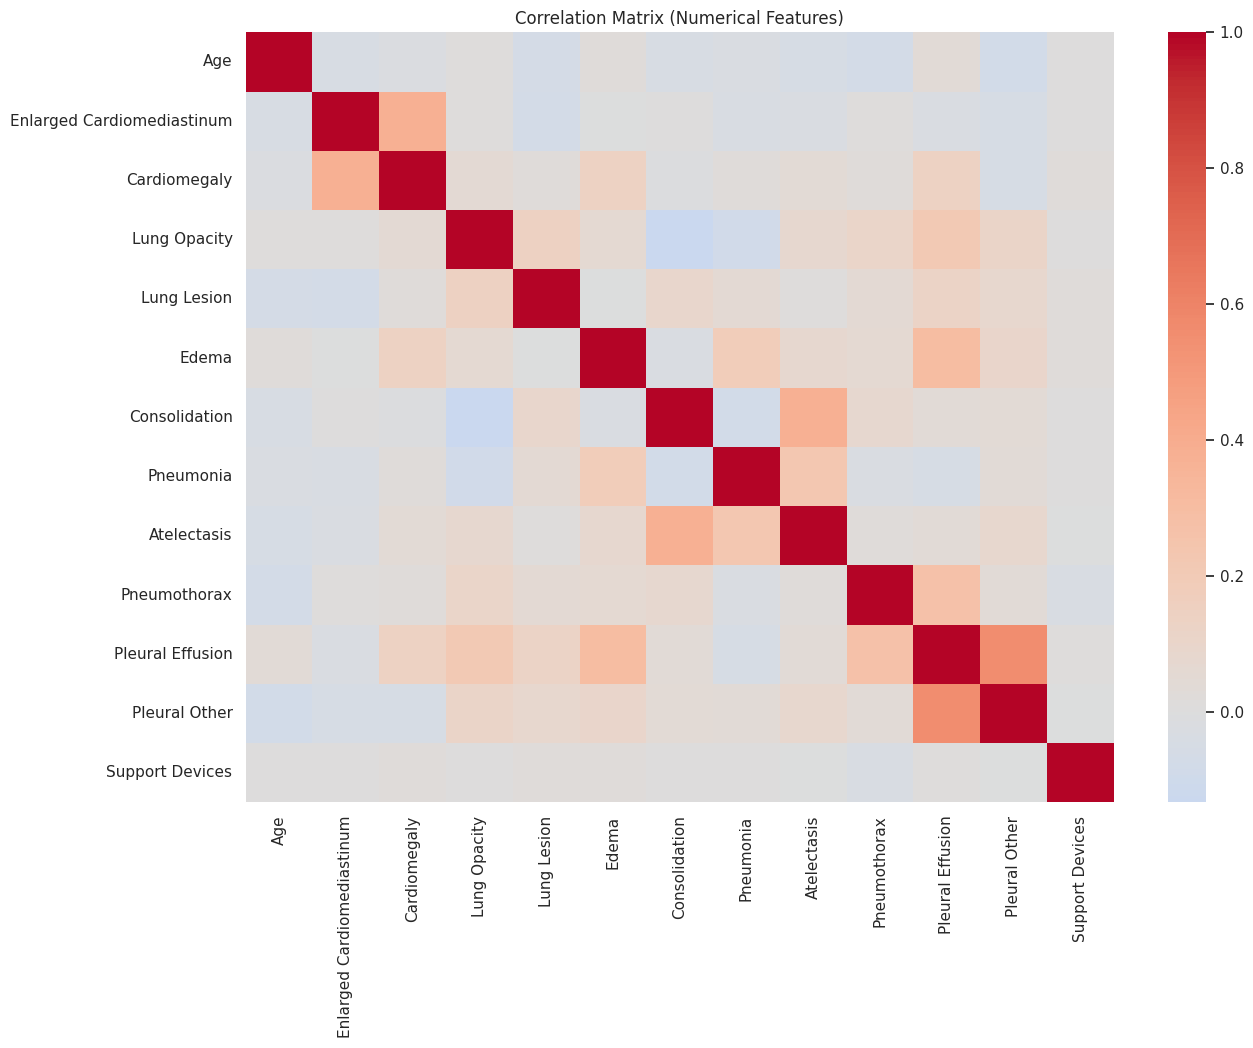

In [34]:
# Select only numeric columns
numeric_cols = train_clean.select_dtypes(include=np.number).columns

plt.figure(figsize=(14,10))
corr = train_clean[numeric_cols].corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

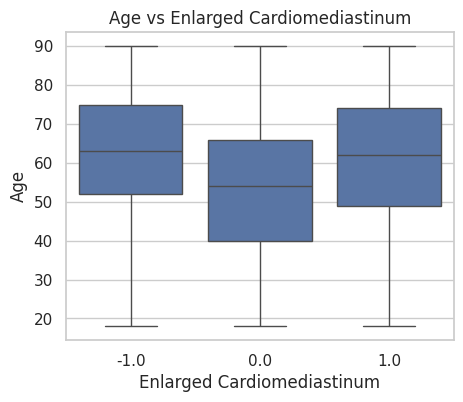

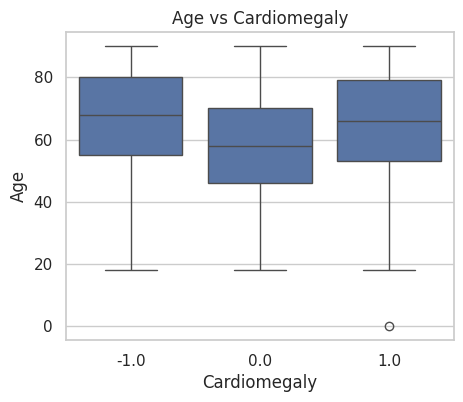

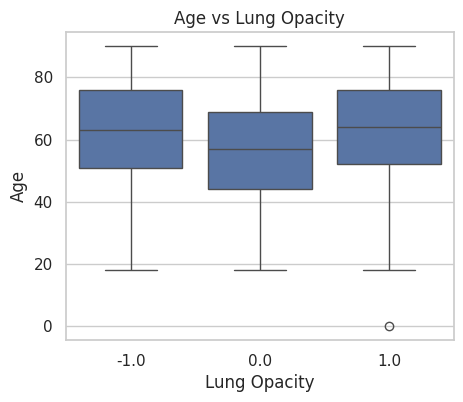

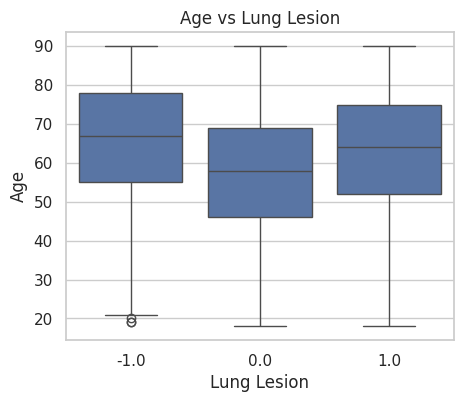

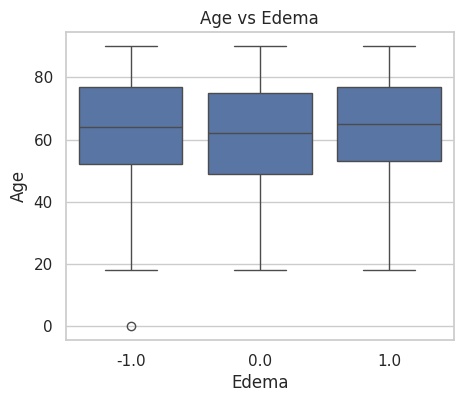

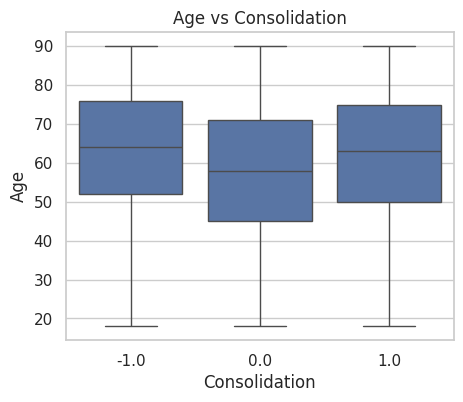

In [35]:
disease_cols = train_clean.select_dtypes(include=np.number).columns.tolist()
disease_cols.remove("Age")

for col in disease_cols[:6]:  # limit for readability
    plt.figure(figsize=(5,4))
    sns.boxplot(x=df[col], y=df["Age"])
    plt.title(f"Age vs {col}")
    plt.show()

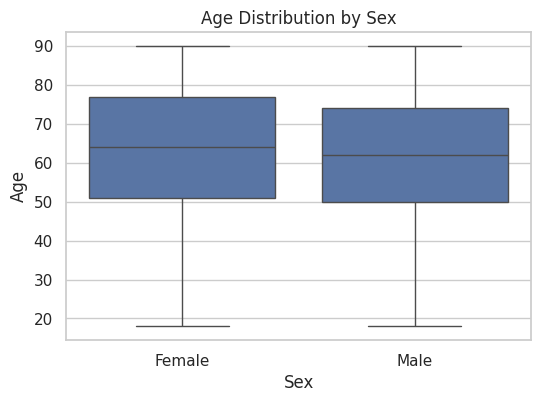

In [36]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Sex", y="Age", data=train_clean)
plt.title("Age Distribution by Sex")
plt.show()

In [37]:
disease_cols = train_clean.select_dtypes(include=np.number).columns.tolist()
disease_cols.remove("Age")

sex_disease = train_clean.groupby("Sex")[disease_cols].mean()

print(sex_disease)

        Enlarged Cardiomediastinum  Cardiomegaly  Lung Opacity  Lung Lesion  \
Sex                                                                           
Female                   -0.075605      0.409598      0.868741     0.659366   
Male                     -0.023379      0.462420      0.865331     0.669866   

           Edema  Consolidation  Pneumonia  Atelectasis  Pneumothorax  \
Sex                                                                     
Female  0.475429       -0.20960  -0.484295    -0.028851      0.245679   
Male    0.486463       -0.20984  -0.479190     0.010499      0.250856   

        Pleural Effusion  Pleural Other  Support Devices  
Sex                                                       
Female          0.610359       0.119901         0.939208  
Male            0.613708       0.143140         0.932027  


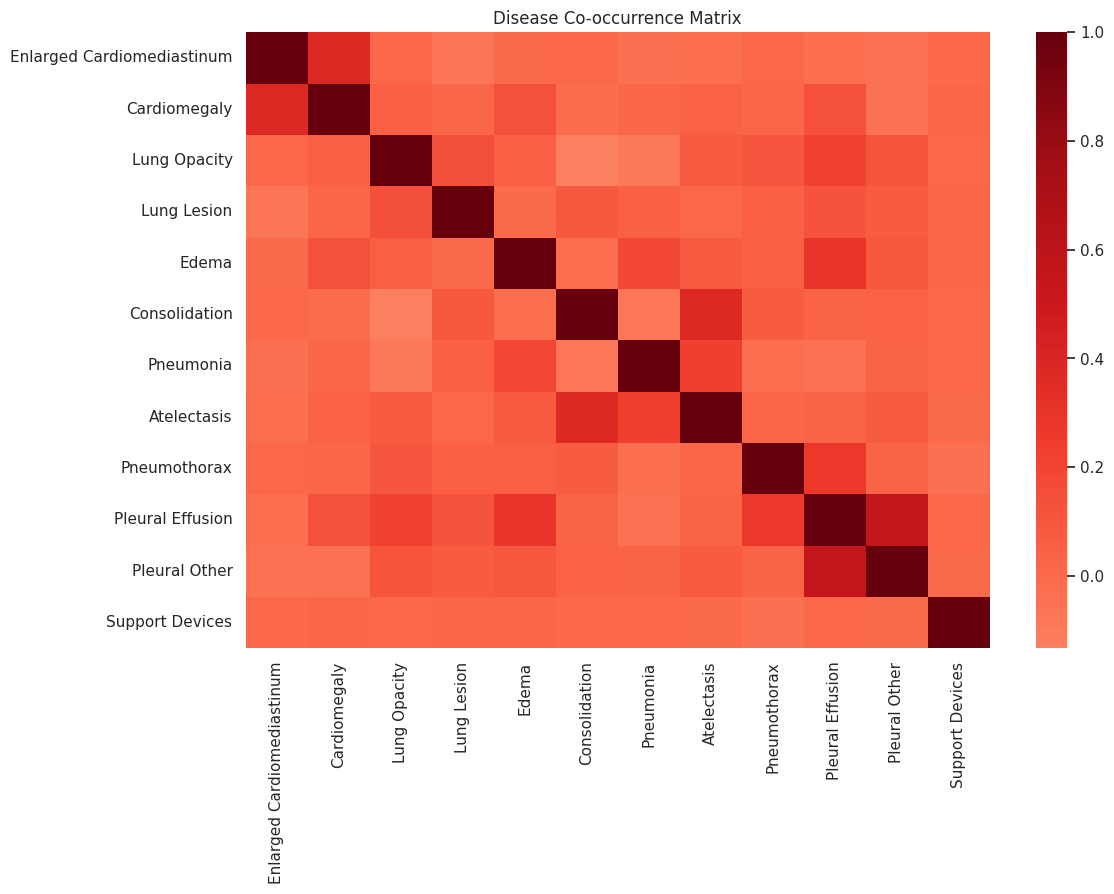

In [38]:
disease_cols = train_encoded.select_dtypes(include=np.number).columns.tolist()
disease_cols.remove("Age")

co_occurrence = train_clean[disease_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(co_occurrence, cmap="Reds", center=0)
plt.title("Disease Co-occurrence Matrix")
plt.show()

# Images 

In [39]:
import matplotlib.pyplot as plt
import cv2
import os

BASE_PATH = "/kaggle/input/datasets/mimsadiislam/chexpert"

def show_samples(df, label, n=5, base_path=BASE_PATH):
    subset = df[df[label] == 1].sample(min(n, len(df[df[label] == 1])), random_state=42)

    plt.figure(figsize=(15, 3))

    shown = 0
    for row in subset.itertuples():
        # Build full path from relative CheXpert path
        img_path = os.path.join(base_path, row.Path)

        img = cv2.imread(img_path)
        if img is None:
            print(f"Could not read: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        shown += 1
        plt.subplot(1, n, shown)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

        if shown == n:
            break

    plt.tight_layout()
    plt.show()

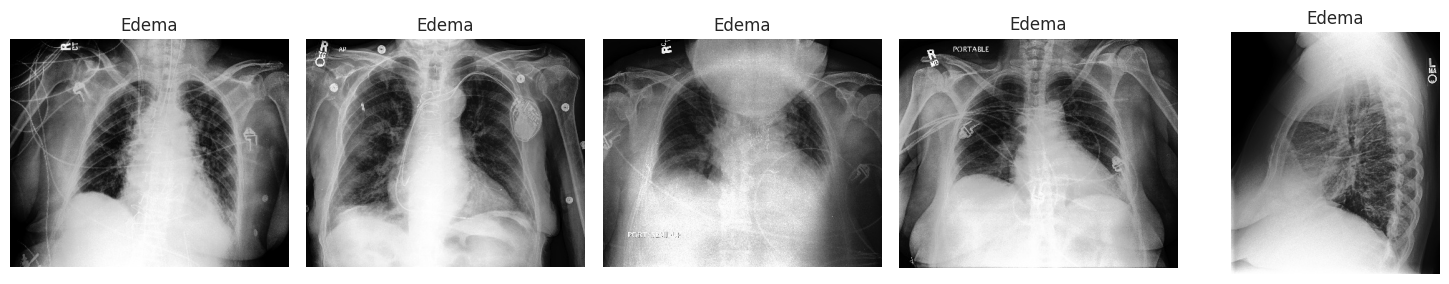

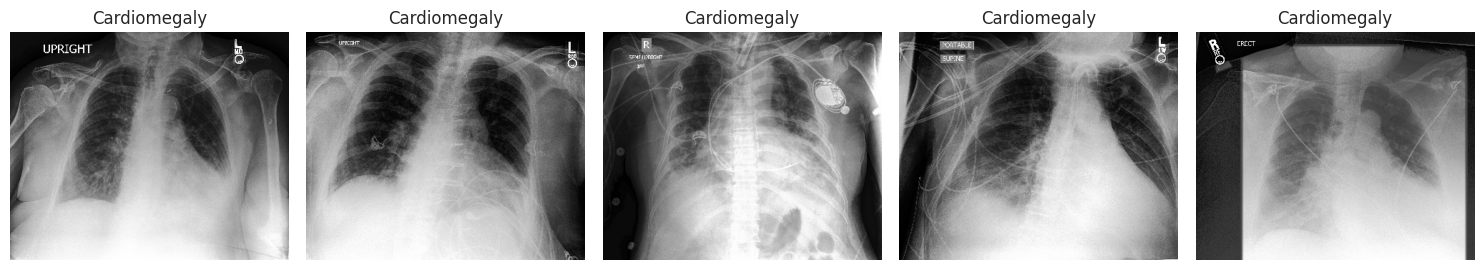

In [40]:
show_samples(train_clean, "Edema")
show_samples(train_clean, "Cardiomegaly")

# Images processing - Feature extraction

In [42]:
# If needed in Kaggle:
# !pip install -q transformers

import os
import numpy as np
import pandas as pd
import torch

from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, ViTModel


def extract_vit_features(
    df: pd.DataFrame,
    base_path: str = "/kaggle/input/datasets/mimsadiislam/chexpert",
    path_col: str = "Path",
    model_name: str = "google/vit-base-patch16-224-in21k",
    batch_size: int = 16,
    device: str = None
):
    """
    Extract transformer-based image embeddings from CheXpert X-rays using ViT.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned dataframe that still contains the Path column.
    base_path : str
        Root Kaggle path prepended to relative CheXpert paths.
    path_col : str
        Name of the image path column.
    model_name : str
        Hugging Face ViT checkpoint.
    batch_size : int
        Batch size for inference.
    device : str
        "cuda" or "cpu". If None, inferred automatically.

    Returns
    -------
    features_df : pd.DataFrame
        DataFrame with one row per input image and columns:
        [Path, vit_0, vit_1, ..., vit_d]
    """

    if path_col not in df.columns:
        raise ValueError(f"'{path_col}' column not found. Keep Path in the cleaned dataframe for image loading.")

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Hugging Face recommends using an image processor for vision models
    processor = AutoImageProcessor.from_pretrained(model_name)
    model = ViTModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    # Build full image paths
    image_paths = []
    for p in df[path_col].tolist():
        if os.path.isabs(p):
            image_paths.append(p)
        else:
            image_paths.append(os.path.join(base_path, p))

    all_features = []
    valid_paths = []

    for start in tqdm(range(0, len(image_paths), batch_size), desc="Extracting ViT features"):
        batch_paths = image_paths[start:start + batch_size]

        images = []
        batch_valid_paths = []

        for img_path in batch_paths:
            try:
                img = Image.open(img_path).convert("RGB")
                images.append(img)
                batch_valid_paths.append(img_path)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

        if len(images) == 0:
            continue

        inputs = processor(images=images, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

            # Use pooled embedding if available; fallback to CLS token
            if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                feats = outputs.pooler_output
            else:
                feats = outputs.last_hidden_state[:, 0, :]

        feats = feats.cpu().numpy()

        all_features.append(feats)
        valid_paths.extend(batch_valid_paths)

    if len(all_features) == 0:
        raise ValueError("No features were extracted. Check the image paths.")

    all_features = np.vstack(all_features)

    feature_cols = [f"vit_{i}" for i in range(all_features.shape[1])]
    features_df = pd.DataFrame(all_features, columns=feature_cols)
    features_df.insert(0, path_col, valid_paths)

    return features_df

In [44]:
train_clean = data_cleaning(train_df)
valid_clean = data_cleaning(valid_df)

train_img_features = extract_vit_features(train_clean[:75])
valid_img_features = extract_vit_features(valid_clean[:25])

print(train_img_features.shape)
print(valid_img_features.shape)

train_img_features.head()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Extracting ViT features:   0%|          | 0/5 [00:00<?, ?it/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Extracting ViT features:   0%|          | 0/2 [00:00<?, ?it/s]

(75, 769)
(25, 769)


,Path,vit_0,vit_1,vit_2,vit_3,vit_4,vit_5,vit_6,vit_7,vit_8,...,vit_758,vit_759,vit_760,vit_761,vit_762,vit_763,vit_764,vit_765,vit_766,vit_767
0,/kaggle/input/datasets/mimsadiislam/chexpert/C...,0.703877,-0.266363,-0.559045,0.031799,0.090587,0.061033,0.391706,0.524319,-0.050732,...,-0.160644,0.527479,-0.277791,-0.040230,0.475111,-0.009057,-0.164166,0.697887,0.250508,0.086499
1,/kaggle/input/datasets/mimsadiislam/chexpert/C...,0.741416,-0.247576,-0.412937,-0.097487,0.135900,-0.042267,0.473613,0.494001,-0.022089,...,-0.179469,0.512072,-0.076463,-0.130301,0.404247,-0.168671,-0.078096,0.759380,0.213569,-0.013170
2,/kaggle/input/datasets/mimsadiislam/chexpert/C...,0.725535,-0.281017,-0.510059,0.050137,0.127655,-0.099614,0.289113,0.397066,-0.056695,...,-0.419984,0.470887,-0.033000,-0.338952,0.417204,0.088821,0.130734,0.672887,0.246429,0.039368
3,/kaggle/input/datasets/mimsadiislam/chexpert/C...,0.702133,-0.173763,-0.403495,-0.144593,0.152741,-0.092018,0.427844,0.492472,-0.117067,...,-0.090160,0.545265,-0.204856,-0.204669,0.453880,-0.195181,-0.004431,0.737032,0.108971,0.096631
4,/kaggle/input/datasets/mimsadiislam/chexpert/C...,0.740769,-0.269330,-0.471474,-0.070502,-0.039064,0.028705,0.425941,0.517715,0.025459,...,-0.222047,0.461572,-0.152395,-0.107180,0.598958,-0.127906,-0.178174,0.780924,0.047937,0.158724


## Full pipeline for data processing

1. clean raw tabular data
2. extract image features using Path
3. preprocess tabular data and drop Path + Frontal/Lateral
4. merge tabular + image features
5. return a model-ready matrix for clustering

In [ ]:
# !pip install -q transformers

import os
import numpy as np
import pandas as pd
import torch

from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, ViTModel


class CheXpertMultimodalPreprocessor:
    """
    End-to-end preprocessing pipeline for CheXpert multimodal clustering.

    Steps:
    1. Clean raw data
    2. Extract transformer-based image features from Path
    3. Encode tabular features
    4. Drop non-informative columns
    5. Merge tabular + image features

    Output:
        DataFrame ready for clustering
    """

    def __init__(
        self,
        base_path="/kaggle/input/chexpert",
        model_name="google/vit-base-patch16-224-in21k",
        batch_size=16,
        device=None,
    ):
        self.base_path = base_path
        self.model_name = model_name
        self.batch_size = batch_size
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.processor = AutoImageProcessor.from_pretrained(self.model_name)
        self.model = ViTModel.from_pretrained(self.model_name).to(self.device)
        self.model.eval()

        self.disease_cols = [
            "Enlarged Cardiomediastinum",
            "Cardiomegaly",
            "Lung Opacity",
            "Lung Lesion",
            "Edema",
            "Consolidation",
            "Pneumonia",
            "Atelectasis",
            "Pneumothorax",
            "Pleural Effusion",
            "Pleural Other",
            "Support Devices",
        ]

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Basic cleaning:
        - remove Fracture and AP/PA
        - remove rows with No Finding == 1, then drop No Finding
        - remove age outliers
        - remove unknown Sex
        """
        df = df.copy()

        # Remove selected columns
        df = df.drop(columns=[c for c in ["Fracture", "AP/PA"] if c in df.columns], errors="ignore")

        # Remove healthy cases and then remove the column
        if "No Finding" in df.columns:
            df = df[df["No Finding"] != 1].copy()
            df = df.drop(columns=["No Finding"])

        # Clean Sex
        if "Sex" in df.columns:
            df["Sex"] = df["Sex"].astype(str).str.strip()
            df = df[~df["Sex"].str.lower().isin(["unknown", "nan", "none", ""])].copy()

        # Clean Age and remove outliers with IQR
        if "Age" in df.columns:
            df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
            df = df[df["Age"].notna()].copy()

            q1 = df["Age"].quantile(0.25)
            q3 = df["Age"].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

            df = df[(df["Age"] >= lower) & (df["Age"] <= upper)].copy()

        return df.reset_index(drop=True)

    def _build_full_path(self, p: str) -> str:
        if os.path.isabs(p):
            return p
        return os.path.join(self.base_path, p)

    def extract_image_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Extract ViT embeddings from image paths.
        Returns a dataframe with Path + vit feature columns.
        """
        if "Path" not in df.columns:
            raise ValueError("Path column is required for image feature extraction.")

        image_paths = [self._build_full_path(p) for p in df["Path"].tolist()]

        all_features = []
        kept_paths = []

        for start in tqdm(range(0, len(image_paths), self.batch_size), desc="Extracting image features"):
            batch_paths = image_paths[start:start + self.batch_size]

            images = []
            batch_kept_paths = []

            for img_path in batch_paths:
                try:
                    img = Image.open(img_path).convert("RGB")
                    images.append(img)
                    batch_kept_paths.append(img_path)
                except Exception as e:
                    print(f"Skipping {img_path}: {e}")

            if not images:
                continue

            inputs = self.processor(images=images, return_tensors="pt")
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                outputs = self.model(**inputs)

                if hasattr(outputs, "pooler_output") and outputs.pooler_output is not None:
                    feats = outputs.pooler_output
                else:
                    feats = outputs.last_hidden_state[:, 0, :]

            feats = feats.cpu().numpy()
            all_features.append(feats)
            kept_paths.extend(batch_kept_paths)

        if not all_features:
            raise ValueError("No image features extracted.")

        all_features = np.vstack(all_features)
        feature_cols = [f"img_feat_{i}" for i in range(all_features.shape[1])]

        features_df = pd.DataFrame(all_features, columns=feature_cols)
        features_df.insert(0, "Path_full", kept_paths)

        return features_df

    def preprocess_tabular(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Encode Sex and disease labels, keep Path for merging.
        Drops Path and Frontal/Lateral from model features later.
        """
        df = df.copy()

        # Keep an absolute path column for merging with extracted image features
        df["Path_full"] = df["Path"].apply(self._build_full_path)

        # One-hot encode Sex
        if "Sex" in df.columns:
            df = pd.get_dummies(df, columns=["Sex"], prefix="Sex")

        # Encode disease columns
        for col in self.disease_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
                # Standardized uncertainty handling for clustering
                df[col] = df[col].replace(-1, 0.5)
                df[col] = df[col].fillna(0)

        # Remove non-clinical / technical columns from final tabular features
        df = df.drop(columns=[c for c in ["Path", "Frontal/Lateral"] if c in df.columns], errors="ignore")

        return df

    def merge_multimodal(self, tabular_df: pd.DataFrame, image_df: pd.DataFrame) -> pd.DataFrame:
        """
        Merge tabular and image features on full path.
        """
        merged = tabular_df.merge(image_df, on="Path_full", how="inner")
        merged = merged.drop(columns=["Path_full"], errors="ignore")
        return merged

    def fit_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Full pipeline on one dataframe.
        """
        clean_df = self.clean_data(df)
        image_features = self.extract_image_features(clean_df)
        tabular_features = self.preprocess_tabular(clean_df)
        multimodal_df = self.merge_multimodal(tabular_features, image_features)
        return multimodal_df

In [ ]:
train_df = pd.read_csv("/kaggle/input/chexpert/CheXpert-v1.0-small/train.csv")
valid_df = pd.read_csv("/kaggle/input/chexpert/CheXpert-v1.0-small/valid.csv")

pipeline = CheXpertMultimodalPreprocessor(
    base_path="/kaggle/input/chexpert",
    model_name="google/vit-base-patch16-224-in21k",
    batch_size=16
)

train_multimodal = pipeline.fit_transform(train_df)
valid_multimodal = pipeline.fit_transform(valid_df)

print("Train multimodal shape:", train_multimodal.shape)
print("Valid multimodal shape:", valid_multimodal.shape)

train_multimodal.head()